In [20]:
%pip install tabulate

import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Text(0.5, 0, 'Years')

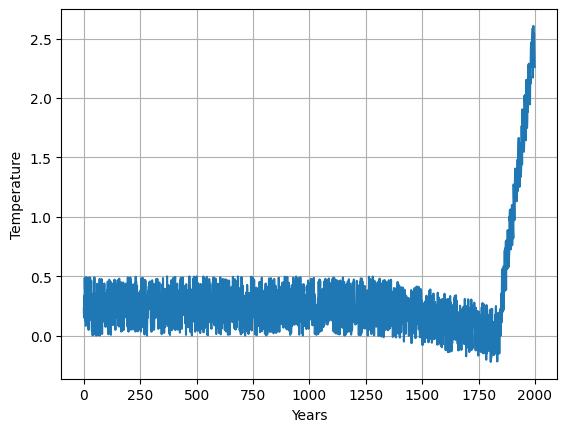

In [ ]:
stdT=.5
observedT=np.zeros([2000,1])
observedT[0:2000]=stdT*np.random.random_sample((2000,1))
observedT[1300:1850]=observedT[1300:1850]-(.25/550)*np.arange(0,550).reshape(-1,1)
observedT[1850:2000]=observedT[1850:2000]+(2.25/150)*np.arange(0,150).reshape(-1,1)
years=np.arange(0,2000)

plt.plot(years,observedT)
plt.grid(True)
plt.ylabel("Temperature")
plt.xlabel("Years")
plt.title("Synthetic Temperature Observations")

Text(0.5, 0, 'Years')

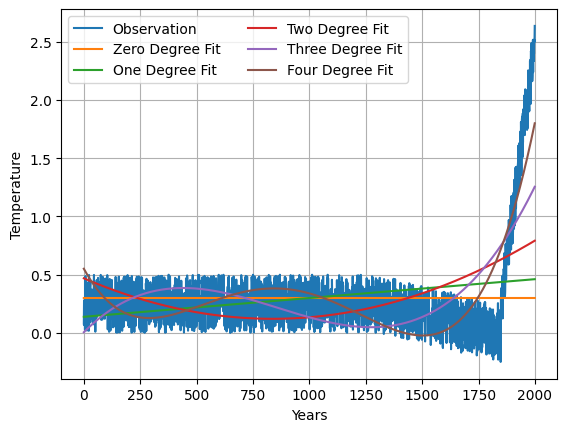

In [ ]:
# try some different fits

zeroDegree=np.polyfit(years,observedT,0)
zeroFit=zeroDegree*np.ones((len(years),1))
oneDegree=np.polyfit(years,observedT,1)
oneFit=oneDegree[0]*years+oneDegree[1]
twoDegree=np.polyfit(years,observedT,2)
twoFit=twoDegree[0]*years**2+twoDegree[1]*years+twoDegree[2]
threeDegree=np.polyfit(years,observedT,3)
threeFit=threeDegree[0]*years**3+threeDegree[1]*years**2+threeDegree[2]*years+threeDegree[3]
fourDegree=np.polyfit(years,observedT,4)
fourFit=fourDegree[0]*years**4+fourDegree[1]*years**3+fourDegree[2]*years**2+fourDegree[3]*years+fourDegree[4]

fig, ax = plt.subplots()
ax.plot(years, observedT, label="Observation")
ax.plot(years, zeroFit, label="Zero Degree Fit")
ax.plot(years, oneFit, label="One Degree Fit")
ax.plot(years, twoFit, label="Two Degree Fit")
ax.plot(years, threeFit, label="Three Degree Fit")
ax.plot(years, fourFit, label="Four Degree Fit")
ax.grid(True)
ax.legend(ncol=2)
plt.ylabel("Temperature")
plt.xlabel("Years")

C:\Users\cambo\AppData\Local\Temp\ipykernel_8328\3507041699.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(ncol=2)


Text(0.5, 0, 'Years')

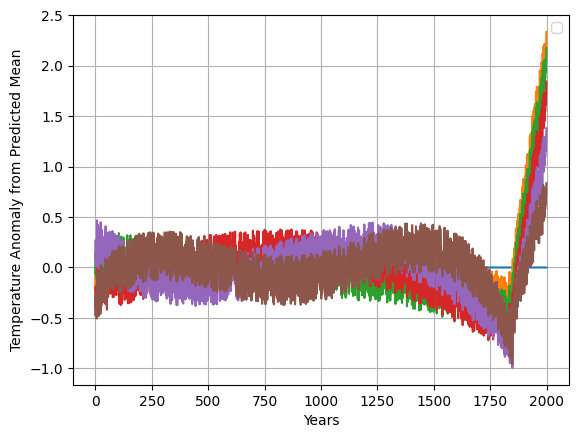

In [ ]:
# make a loss function

fig, ax = plt.subplots()

noLoss=observedT-observedT
plt.plot(years, noLoss);
zeroLoss=observedT-zeroFit.reshape(-1,1)
plt.plot(years, zeroLoss);
oneLoss=observedT-oneFit.reshape(-1,1)
plt.plot(years, oneLoss);
twoLoss=observedT-twoFit.reshape(-1,1)
plt.plot(years, twoLoss);
threeLoss=observedT-threeFit.reshape(-1,1)
plt.plot(years, threeLoss);
fourLoss=observedT-fourFit.reshape(-1,1)
plt.plot(years, fourLoss);
ax.grid(True)
ax.legend(ncol=2)
plt.ylabel("Temperature Anomaly from Predicted Mean")
plt.xlabel("Years")
plt.title("Loss Function")


In [ ]:
# calculate total cost
costZero=sum(zeroLoss[0:1300])
costOne=sum(oneLoss[0:1300])
costTwo=sum(twoLoss[0:1300])
costThree=sum(threeLoss[0:1300])
costFour=sum(fourLoss[0:1300])


data = [['Zero', costZero], ['One', costOne], ['Two', costTwo], ['Three', costThree], ['Four', costFour]]
print(tabulate(data, headers=['DoF', 'Cost'], tablefmt='grid'))

+-------+----------------+
| DoF   | Cost           |
+=======+================+
| Zero  | [-60.46977759] |
+-------+----------------+
| One   | [12.96985778]  |
+-------+----------------+
| Two   | [58.12052717]  |
+-------+----------------+
| Three | [29.09937168]  |
+-------+----------------+
| Four  | [-15.1704029]  |
+-------+----------------+
